<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Week4_3/blob/main/Week4_optimizacion_red_neuronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 4 – Optimización en una Red Neuronal

**Aplicación de Técnicas de Optimización en una Red Neuronal**

Objetivo: analizar cómo cambia el proceso de aprendizaje de una red neuronal cuando se modifican técnicas de optimización, manteniendo constante el resto de la configuración.


## 1. Importación de librerías
Se importan las librerías necesarias para manejo de datos, visualización y construcción de redes neuronales.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## 2. Carga y preparación del dataset
Se utiliza el dataset MNIST. Las imágenes se normalizan y las etiquetas se convierten a formato one-hot.

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 3. Definición del modelo base
Se define una función que construye la arquitectura de la red neuronal. Esta arquitectura se mantendrá constante para todos los experimentos, garantizando una comparación justa.

In [ ]:
def crear_modelo():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(784,)),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

## 4. Entrenamiento con SGD
Se entrena el modelo utilizando el optimizador **Stochastic Gradient Descent (SGD)** con una tasa de aprendizaje de 0.01.

In [ ]:
modelo_sgd = crear_modelo()
modelo_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_sgd = modelo_sgd.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5257 - loss: 1.6738 - val_accuracy: 0.7671 - val_loss: 0.9565
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8109 - loss: 0.7288 - val_accuracy: 0.8635 - val_loss: 0.5314
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8669 - loss: 0.4949 - val_accuracy: 0.8902 - val_loss: 0.4111
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8869 - loss: 0.4094 - val_accuracy: 0.9028 - val_loss: 0.3582
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8976 - loss: 0.3656 - val_accuracy: 0.9100 - val_loss: 0.3281
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9050 - loss: 0.3376 - val_accuracy: 0.9137 - val_loss: 0.3084
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9096 - loss: 0.3174 - val_accuracy: 0.9187 - val_loss: 0.2910
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9136 - loss: 0.3013 - val_accuracy: 0

## 5. Entrenamiento con Adam
Se entrena el mismo modelo base utilizando el optimizador **Adam**, el cual adapta dinámicamente la tasa de aprendizaje.

In [ ]:
modelo_adam = crear_modelo()
modelo_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_adam = modelo_adam.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8605 - loss: 0.5015 - val_accuracy: 0.9316 - val_loss: 0.2278
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9429 - loss: 0.1989 - val_accuracy: 0.9495 - val_loss: 0.1748
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9565 - loss: 0.1495 - val_accuracy: 0.9575 - val_loss: 0.1446
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9644 - loss: 0.1222 - val_accuracy: 0.9609 - val_loss: 0.1344
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9705 - loss: 0.1021 - val_accuracy: 0.9668 - val_loss: 0.1154
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9750 - loss: 0.0850 - val_accuracy: 0.9652 - val_loss: 0.1212
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9776 - loss: 0.0741 - val_accuracy: 0.9682 - val_loss: 0.1056
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9805 - loss: 0.0646 - val_accuracy: 0.

## 6. Comparación del entrenamiento
Se visualiza la evolución de la función de pérdida (loss) para ambos optimizadores.

NameError: name 'hist_adam' is not defined

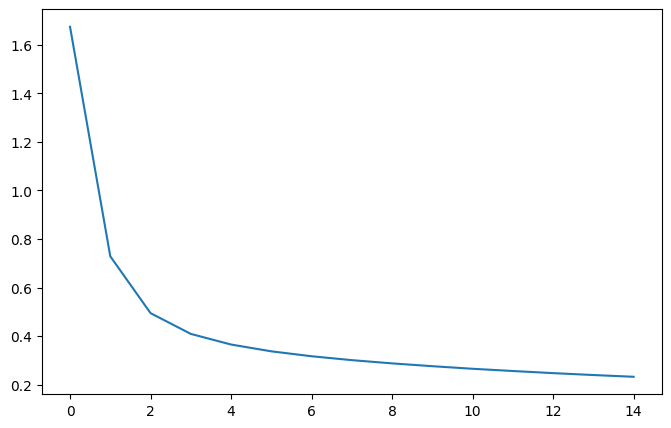

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hist_sgd.history['loss'], label='SGD')
plt.plot(hist_adam.history['loss'], label='Adam')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Comparación del Loss durante el entrenamiento')
plt.legend()
plt.grid()
plt.show()

## 7. Validacion del modelo
Se evalúa cada modelo utilizando el conjunto de prueba (test).

In [ ]:
loss_sgd, acc_sgd = modelo_sgd.evaluate(X_test, y_test, verbose=0)
loss_adam, acc_adam = modelo_adam.evaluate(X_test, y_test, verbose=0)
print(f'SGD  -> Loss: {loss_sgd:.4f}, Accuracy: {acc_sgd:.4f}')
print(f'Adam -> Loss: {loss_adam:.4f}, Accuracy: {acc_adam:.4f}')

SGD  -> Loss: 0.2244, Accuracy: 0.9359
Adam -> Loss: 0.1015, Accuracy: 0.9732


## 8. Conclusiones
- Adam presenta una convergencia más rápida que SGD.
- SGD es más sensible a la tasa de aprendizaje.
- La selección del optimizador impacta directamente en la estabilidad y velocidad de aprendizaje.